In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Flatten, Input, Activation
from tensorflow.keras.layers import Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

In [2]:
import numpy as np
from pathlib import Path

In [3]:
import sys
sys.path.append("..")
from dataset import make_sr_dataset
import matplotlib.pyplot as plt

2.20.0


In [4]:
ROOT = Path("../data/raw/Flickr2K")
path = [str(p) for p in ROOT.glob('*.png')]


np.random.seed(7)
np.random.shuffle(path)

In [5]:
HR_SIZE = 128
SCALE = 2
LR_SIZE = 64
BATCH = 8
EPOCHS = 10

In [6]:
test_paths = path[2120+265 :]
ds_test = make_sr_dataset(test_paths,HR_SIZE,SCALE,BATCH,False)
lr,hr = next(iter(ds_test))

In [7]:
autoencoder = tf.keras.models.load_model(
    "../models/sr_autoencoder.keras",compile = False
)

print("Model loaded.")

Model loaded.


In [8]:
lr_up = tf.image.resize(lr,(128,128), method = 'bicubic')
lr_up = tf.clip_by_value(lr_up,0.0,1.0)

In [9]:
pred = autoencoder(lr,training = False)

In [10]:
psnr_model = tf.image.psnr(hr,pred,max_val = 1.0)
psnr_bicubic = tf.image.psnr(hr,lr_up,max_val=1.0)

print('PSNR model mean:',tf.reduce_mean(psnr_model).numpy())
print('PSNR bicubic mean:',tf.reduce_mean(psnr_bicubic).numpy())

PSNR model mean: 21.342447
PSNR bicubic mean: 32.34319


In [11]:
psnr_model_all = []
psnr_bicubic_all = []

for lr, hr in ds_test:
    pred = autoencoder(lr, training=False)

    lr_up = tf.image.resize(lr, (tf.shape(hr)[1], tf.shape(hr)[2]), method="bicubic")
    lr_up = tf.clip_by_value(lr_up, 0.0, 1.0)

    psnr_model = tf.image.psnr(hr, pred, max_val=1.0)
    psnr_bicubic = tf.image.psnr(hr, lr_up, max_val=1.0)

    psnr_model_all.append(tf.reduce_mean(psnr_model).numpy())
    psnr_bicubic_all.append(tf.reduce_mean(psnr_bicubic).numpy())

mean_model = sum(psnr_model_all) / len(psnr_model_all)
mean_bicubic = sum(psnr_bicubic_all) / len(psnr_bicubic_all)

print(f"TEST PSNR bicubic: {mean_bicubic:.3f} dB")
print(f"TEST PSNR model:   {mean_model:.3f} dB")
print(f"GAIN:              {mean_model - mean_bicubic:+.3f} dB")

TEST PSNR bicubic: 34.730 dB
TEST PSNR model:   22.997 dB
GAIN:              -11.733 dB


2026-03-09 12:39:08.500449: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


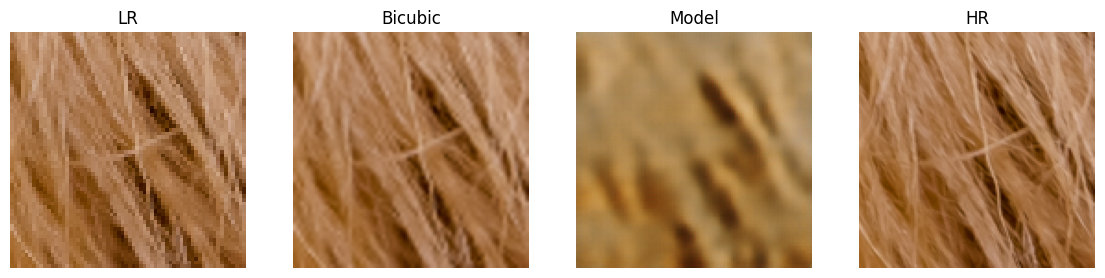

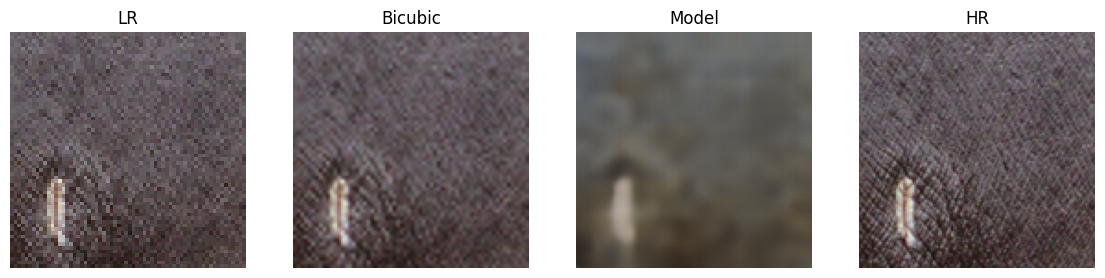

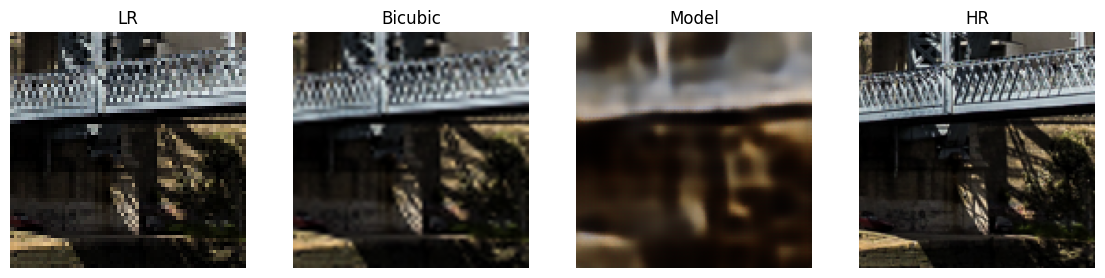

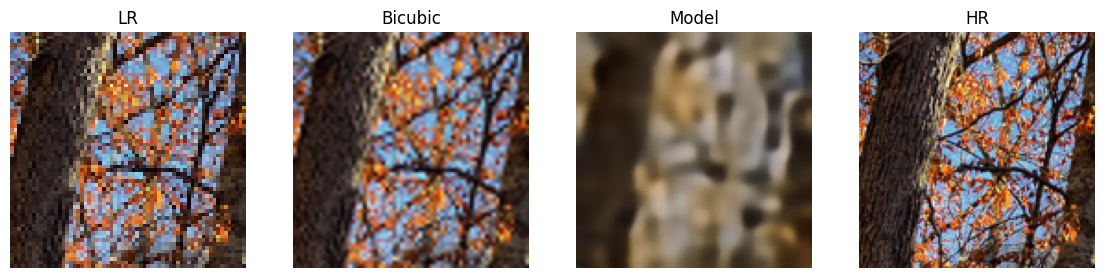

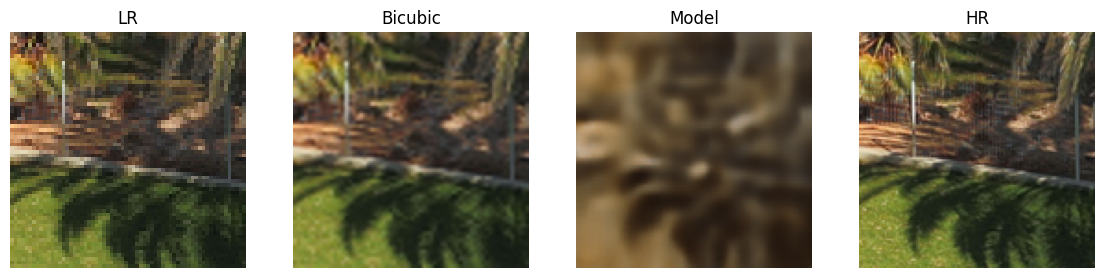

In [12]:
lr, hr = next(iter(ds_test))
pred = autoencoder(lr, training=False)
lr_up = tf.image.resize(lr, (128, 128), method="bicubic")
lr_up = tf.clip_by_value(lr_up, 0.0, 1.0)

for i in range(5):
    plt.figure(figsize=(14,4))

    plt.subplot(1,4,1); plt.title("LR"); plt.imshow(lr[i]); plt.axis("off")
    plt.subplot(1,4,2); plt.title("Bicubic"); plt.imshow(lr_up[i]); plt.axis("off")
    plt.subplot(1,4,3); plt.title("Model"); plt.imshow(pred[i]); plt.axis("off")
    plt.subplot(1,4,4); plt.title("HR"); plt.imshow(hr[i]); plt.axis("off")

    plt.show()

In [13]:
lr, hr = next(iter(ds_test))
pred = autoencoder(lr, training=False)

lr_up = tf.image.resize(lr, (tf.shape(hr)[1], tf.shape(hr)[2]), method="bicubic")
lr_up = tf.clip_by_value(lr_up, 0.0, 1.0)

print("LR shape:", lr.shape)
print("HR shape:", hr.shape)
print("Pred shape:", pred.shape)
print("LR_up shape:", lr_up.shape)

print("SCALE (expected 2):", SCALE)
print("MAE bicubic:", tf.reduce_mean(tf.abs(hr - lr_up)).numpy())
print("MAE model:  ", tf.reduce_mean(tf.abs(hr - pred)).numpy())

print("PSNR bicubic:", tf.reduce_mean(tf.image.psnr(hr, lr_up, max_val=1.0)).numpy())
print("PSNR model:  ", tf.reduce_mean(tf.image.psnr(hr, pred, max_val=1.0)).numpy())

LR shape: (8, 64, 64, 3)
HR shape: (8, 128, 128, 3)
Pred shape: (8, 128, 128, 3)
LR_up shape: (8, 128, 128, 3)
SCALE (expected 2): 2
MAE bicubic: 0.03868143
MAE model:   0.09314703
PSNR bicubic: 26.765862
PSNR model:   19.212627
